# Линейное программирование



### Упражнение 24.1 (Простота и наглядность)
* Построить целевую функцию
* Построить прямые, определяющие ограничения!
* Определить точки пересечения прямых
* Определить решение графически.

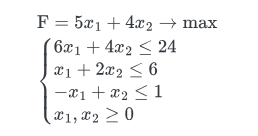
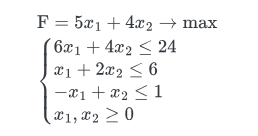

Оптимальная точка: x1 = 3.00, x2 = 1.50
Максимальное значение F = 21.00


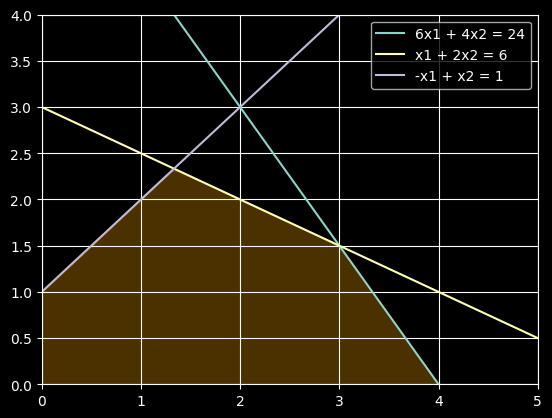

In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 5, 100)

y1 = (24 - 6*x) / 4  # из 6x1 + 4x2 <= 24
y2 = (6 - x) / 2     # из x1 + 2x2 <= 6
y3 = 1 + x           # из -x1 + x2 <= 1


plt.plot(x, y1, label='6x1 + 4x2 = 24')
plt.plot(x, y2, label='x1 + 2x2 = 6')
plt.plot(x, y3, label='-x1 + x2 = 1')

y_min = np.minimum(y1, np.minimum(y2, y3))
plt.fill_between(x, 0, y_min, where=(y_min >= 0), color='orange', alpha=0.3)


print(f"Оптимальная точка: x1 = {3:.2f}, x2 = {1.5:.2f}")
print(f"Максимальное значение F = {21:.2f}")

plt.xlim(0, 5)
plt.ylim(0, 4)
plt.legend()
plt.grid()
plt.show()

### Упражнение 24.2 (Пакет с пакетами)
 С помощью пакета Приложение G получить решение задачи. Используйте, Глава G.1 или Глава G.2 на своё усмотрение.

In [6]:
import numpy as np
from scipy.optimize import linprog

c = np.array([
    -3, -4, -2, -5, -6, -7, -8, -9, -10, -11
])

A_ub = np.array([
    [1, 2, 3, 1, 4, 6, 0, 7, 8, 9],
    [2, 1, 2, 3, 2, 3, 4, 5, 1, 3],
    [3, 4, 1, 4, 5, 2, 1, 3, 2, 1],
    [4, 2, 5, 1, 2, 3, 5, 6, 2, 4],
    [1, 2, 5, 1, 2, 4, 5, 1, 1, 3],
    [5, 6, 1, 3, 4, 5, 6, 7, 1, 2],
    [2, 3, 4, 1, 4, 3, 2, 5, 7, 8]
])

b_ub = np.array([
    30, 20, 25, 25, 18, 22, 19
])

res = linprog(c, A_ub=A_ub, b_ub=b_ub, method='simplex')


if res.success:

    max_F = -res.fun
    print(f"Максимальное значение функции F = {max_F:.4f}\n")
    print("Оптимальные значения переменных:")
    for i, x_val in enumerate(res.x):
        if x_val > 1e-8:
            print(f"x_{i+1:<2} = {x_val:.4f}")
        else:
            print(f"x_{i+1:<2} = 0.0000")

Максимальное значение функции F = 49.2500

Оптимальные значения переменных:
x_1  = 0.0000
x_2  = 0.0000
x_3  = 0.0000
x_4  = 4.7500
x_5  = 0.0000
x_6  = 0.0000
x_7  = 1.0000
x_8  = 0.0000
x_9  = 1.7500
x_10 = 0.0000


/tmp/ipykernel_6816/3863825566.py:22: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  res = linprog(c, A_ub=A_ub, b_ub=b_ub, method='simplex')


### Упражнение 24.3 (Учебный план)
Для новых специальностей на факультете радиофизики запланировано 3500 учебных часов. Основные разделы подготовки студентов и затраты на разработку приведены ниже.
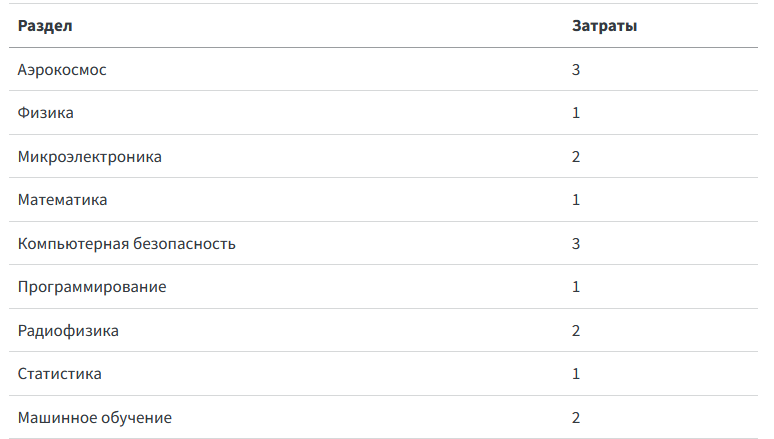

Соотношение между часами учебных дисциплин должно быть не меньше, чем указано в диаграмме

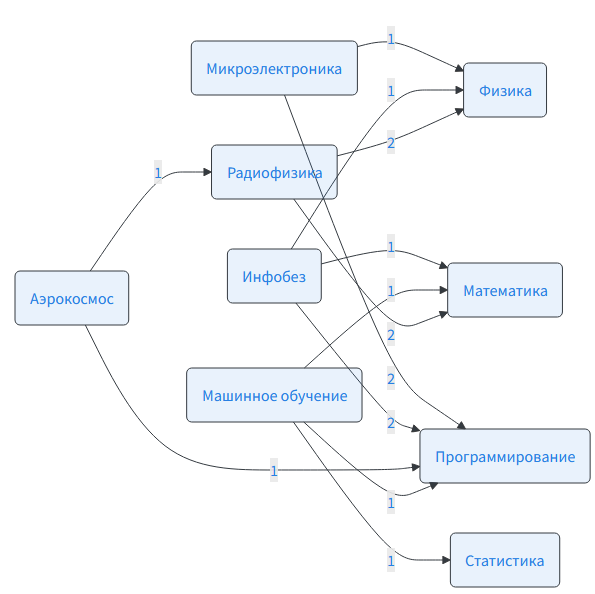

Согласно положению за период обучения должно быть прочитано часов не менее

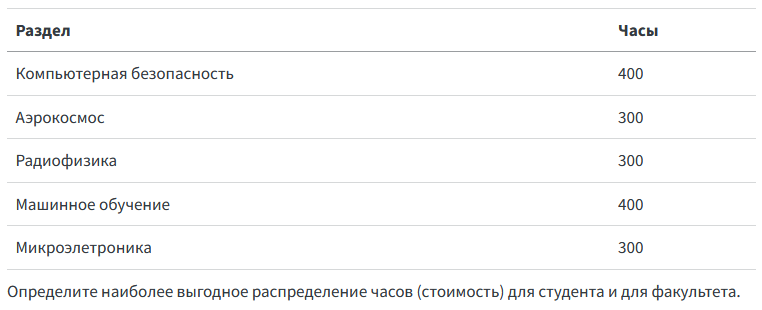

In [7]:
import numpy as np
from scipy.optimize import linprog

subjects = ['Aero', 'Phys', 'Micro', 'Math', 'CompSec', 'Prog', 'Radio', 'Stat', 'ML']
idx = {name: i for i, name in enumerate(subjects)}

costs = np.array([3, 1, 2,
1, 3, 1, 2, 1, 2])

bounds = [(0, None)] * len(subjects)
bounds[idx['CompSec']] = (400, None)
bounds[idx['Aero']]    = (300, None)
bounds[idx['Radio']]   = (300, None)
bounds[idx['ML']]      = (400, None)
bounds[idx['Micro']]   = (300, None)

A_eq = [np.ones(len(subjects))]
b_eq = [3500]


A_ub = []
b_ub = []

# -A + kB <= 0
def add_ratio_constraint(subj_A, subj_B, k):

    row = np.zeros(len(subjects))
    row[idx[subj_A]] = -1.0
    row[idx[subj_B]] = k
    A_ub.append(row)
    b_ub.append(0)

# subjects = ['Aero', 'Phys', 'Micro', 'Math', 'CompSec', 'Prog', 'Radio', 'Stat', 'ML']

add_ratio_constraint('Aero', 'Radio', 1.0)
add_ratio_constraint('Aero', 'Prog', 1.0)
add_ratio_constraint('Radio', 'Phys', 2.0)
add_ratio_constraint('Radio', 'Math', 2.0)
add_ratio_constraint('Micro', 'Prog', 2.0)
add_ratio_constraint('Micro', 'Phys', 1.0)
add_ratio_constraint('CompSec','Phys', 1.0)
add_ratio_constraint('CompSec', 'Math', 1.0)
add_ratio_constraint('CompSec', 'Prog', 2.0)
add_ratio_constraint('ML', 'Math', 1.0)
add_ratio_constraint('ML', 'Prog', 1.0)
add_ratio_constraint('ML', 'Stat', 1.0)


lp_args = {
    'A_eq': A_eq,
    'b_eq': b_eq,
    'bounds': bounds,
    'method': 'highs'
}
if len(A_ub) > 0:
    lp_args['A_ub'] = np.array(A_ub)
    lp_args['b_ub'] = np.array(b_ub)



def print_solution(res, is_student=False):
        cost = -res.fun if is_student else res.fun
        print(f"Суммарная стоимость: {cost:.2f} у.е.")
        print("Распределение часов:")
        for name, i in idx.items():
            if res.x[i] > 1e-8:
                print(f"  - {name:<8}: {res.x[i]:.1f} ч.")

print("="*50)
print(" РЕШЕНИЕ ДЛЯ ФАКУЛЬТЕТА (Минимизация затрат)")
print("="*50)

res_faculty = linprog(c=costs, **lp_args)
print_solution(res_faculty, is_student=False)

print("\n" + "="*50)
print(" РЕШЕНИЕ ДЛЯ СТУДЕНТА (Максимизация стоимости)")
print("="*50)

res_student = linprog(c=-costs, **lp_args)
print_solution(res_student, is_student=True)

 РЕШЕНИЕ ДЛЯ ФАКУЛЬТЕТА (Минимизация затрат)
Суммарная стоимость: 6375.00 у.е.
Распределение часов:
  - Aero    : 300.0 ч.
  - Phys    : 150.0 ч.
  - Micro   : 300.0 ч.
  - Math    : 150.0 ч.
  - CompSec : 400.0 ч.
  - Prog    : 150.0 ч.
  - Radio   : 300.0 ч.
  - Stat    : 875.0 ч.
  - ML      : 875.0 ч.

 РЕШЕНИЕ ДЛЯ СТУДЕНТА (Максимизация стоимости)
Суммарная стоимость: 9500.00 у.е.
Распределение часов:
  - Aero    : 300.0 ч.
  - Micro   : 300.0 ч.
  - CompSec : 2200.0 ч.
  - Radio   : 300.0 ч.
  - ML      : 400.0 ч.


### Упражнение 24.4 (Работа не волк, а work)
 Лишенный стипендии студент для поддержания своего финансового уровня должен подрабатывать и получить не менее 700 руб в месяц. У него есть следующие альтернативы

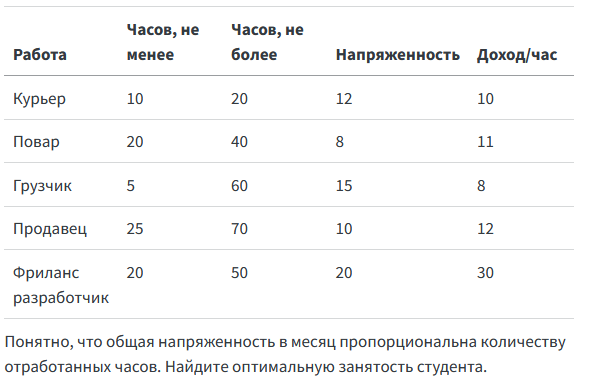

In [8]:
import numpy as np
from scipy.optimize import linprog
from itertools import product

names = ["Курьер", "Повар", "Грузчик", "Продавец", "Фриланс"]
L = np.array([10, 20, 5, 25, 20])
U = np.array([20, 40, 60, 70, 50])


time_cost = np.array([12, 8, 15, 10, 20])

income = np.array([10, 11, 8, 12, 30])
target_income = 700

best_time = np.inf
best_x = None
best_combo = None

for combo in product([0, 1], repeat=5):

    active = np.array(combo)

    if np.sum(active) == 0:
        continue

    current_bounds = [(L[i], U[i]) if active[i] else (0, 0) for i in range(5)]

    A_ub = [-income]
    b_ub = [-target_income]

    res = linprog(time_cost, A_ub=A_ub, b_ub=b_ub, bounds=current_bounds, method='highs')

    if res.success and res.fun < best_time:
        best_time = res.fun
        best_x = res.x
        best_combo = active

print("--- ОПТИМАЛЬНАЯ СТРАТЕГИЯ ДЛЯ МИНИМУМА ВРЕМЕНИ ---")

if best_x is not None:
    total_income = 0
    total_hours = 0

    for i in range(5):
        if best_combo[i]:
            h = best_x[i]
            inc = h * income[i]
            total_income += inc
            total_hours += h
            print(f"[{names[i]:<8}] Отработать часов: {h:>5.2f} (Доход: {inc:>6.2f} руб.)")

    print("-" * 50)
    print(f"Итоговый доход:            {total_income:.2f} руб. (Требовалось >= {target_income})")
    print(f"Суммарные затраты времени: {total_hours:.2f} часов.")

    print("\n--- Анализ эффективности (Доход на 1 час времени) ---")
    for i in np.argsort(-income):
        print(f"{names[i]:<10}: {income[i]} руб/час")

--- ОПТИМАЛЬНАЯ СТРАТЕГИЯ ДЛЯ МИНИМУМА ВРЕМЕНИ ---
[Фриланс ] Отработать часов: 23.33 (Доход: 700.00 руб.)
--------------------------------------------------
Итоговый доход:            700.00 руб. (Требовалось >= 700)
Суммарные затраты времени: 23.33 часов.

--- Анализ эффективности (Доход на 1 час времени) ---
Фриланс   : 30 руб/час
Продавец  : 12 руб/час
Повар     : 11 руб/час
Курьер    : 10 руб/час
Грузчик   : 8 руб/час


In [9]:
import numpy as np
from scipy.optimize import linprog

cost = {'veg': 3, 'groats': 1, 'meat': 12, 'pasta': 5}

c_soup = (2/6)*cost['veg'] + (3/6)*cost['groats'] + (1/6)*cost['meat']

c_side = (1/2)*cost['veg'] + (1/2)*cost['groats']

c_main = (3/5)*cost['meat'] + (2/5)*cost['pasta']

c_salad = (1/9)*cost['meat'] + (8/9)*cost['veg']

c = np.array([c_soup, c_side, c_main, c_salad])

A_ub = np.array([
    [2/6, 1/2, 0,   8/9],  # Овощи
    [3/6, 1/2, 0,   0  ],  # Крупа
    [1/6, 0,   3/5, 1/9],  # Мясо
    [0,   0,   2/5, 0  ]   # Макароны
])

b_ub = np.array([50, 30, 10, 20])

bounds = [
    (15, None),  # Супы >= 15
    (20, None),  # Гарнир >= 20
    (10, None),  # Горячее >= 10
    (5,  None)   # Салаты >= 5
]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

print("="*50)
print(" ЧАСТЬ 1: ОПТИМАЛЬНЫЙ ПРОИЗВОДСТВЕННЫЙ ПЛАН (Минимизация)")
print("="*50)
dishes = ['Супы', 'Гарниры', 'Горячее', 'Салаты']
print(f"Минимальные суммарные издержки: {res.fun:.2f} руб.\n")

print("План производства (кг):")
for i, name in enumerate(dishes):
    print(f"  - {name:<8}: {res.x[i]:>5.2f} кг (Себестоимость: {c[i]:.2f} руб/кг)")

print("\nПотребность в ингредиентах (кг) и остатки:")
ingredients = ['Овощи', 'Крупа', 'Мясо', 'Макароны']
usage = A_ub.dot(res.x)
for i, name in enumerate(ingredients):
    slack = b_ub[i] - usage[i]
    print(f"  - {name:<8}: потрачено {usage[i]:>5.2f} из {b_ub[i]:<2} (Остаток: {slack:>5.2f} кг)")

 ЧАСТЬ 1: ОПТИМАЛЬНЫЙ ПРОИЗВОДСТВЕННЫЙ ПЛАН (Минимизация)
Минимальные суммарные издержки: 204.50 руб.

План производства (кг):
  - Супы    : 15.00 кг (Себестоимость: 3.50 руб/кг)
  - Гарниры : 20.00 кг (Себестоимость: 2.00 руб/кг)
  - Горячее : 10.00 кг (Себестоимость: 9.20 руб/кг)
  - Салаты  :  5.00 кг (Себестоимость: 4.00 руб/кг)

Потребность в ингредиентах (кг) и остатки:
  - Овощи   : потрачено 19.44 из 50 (Остаток: 30.56 кг)
  - Крупа   : потрачено 17.50 из 30 (Остаток: 12.50 кг)
  - Мясо    : потрачено  9.06 из 10 (Остаток:  0.94 кг)
  - Макароны: потрачено  4.00 из 20 (Остаток: 16.00 кг)


1. При какой наименьшей стоимости имеет смысл производить?
   -> Чтобы производство имело экономический смысл, отпускная цена (продажа)
      каждого блюда должна быть СТРОГО БОЛЬШЕ его себестоимости.

2. Как изменится решение, если стоимость блюда изменится?
   -> Если отпускная цена превысит себестоимость, целевая функция сменится с
      «минимизации затрат» на «максимизацию прибыли».

3. Как изменится решение, если изменится ограничение?
   -> Изменение лимитов сырья не влияет на план в текущей модели минимизации (т.к.
      нам и так хватает ресурсов для закрытия базового спроса). Однако при задаче
      на прибыль увеличение "узких" лимитов позволит нарастить объем производства.

4. Как существенно повысить прибыль, если есть всего одна возможность?
   -> Изучив остатки мы видим, что самое дефицитное сырье — это Мясо.
      На базовый план уходит 9.06 кг из 10 доступных (запас менее 1 кг).
      Остального сырья в избытке (остаток овощей ~30 кг, макарон ~16 кг).
      ВЫВОД: Единственная возможность кратно повысить прибыль увеличить количество мяса.

### Упражнение 24.6 (Враг в отражении)
 Решите двойственную к следующей задачу ЛП, а затем найдите оптимальное решение прямой задачи. Даёт ли в этом случае вычислительное преимущество по сравнению с решением прямой задачи ЛП?
 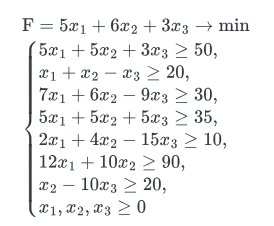

In [10]:
import numpy as np
from scipy.optimize import linprog

c_dual = np.array([-50, -20, -30, -35, -10, -90, -20])

A_ub_dual = np.array([
    [5,  1,  7,  5,   2, 12,   0], # для y1..y7 из x1
    [5,  1,  6,  5,   4, 10,   1], # для y1..y7 из x2
    [3, -1, -9,  5, -15,  0, -10]  # для y1..y7 из x3
])

b_ub_dual = np.array([5, 6, 3])

res_dual = linprog(c_dual, A_ub=A_ub_dual, b_ub=b_ub_dual, method='highs')

c_primal = np.array([5, 6, 3])

A_ub_primal = np.array([
    [-5,  -5,  -3],
    [-1,  -1,   1],
    [-7,  -6,   9],
    [-5,  -5,  -5],
    [-2,  -4,  15],
    [-12, -10,  0],
    [ 0,  -1,  10]
])

b_ub_primal = np.array([-50, -20, -30, -35, -10, -90, -20])

res_primal = linprog(c_primal, A_ub=A_ub_primal, b_ub=b_ub_primal, method='highs')

print("--- ДВОЙСТВЕННАЯ ЗАДАЧА ---")
if res_dual.success:
    print(f"Максимум W = {-res_dual.fun:.2f}")
    print("Оптимальные значения Y (округлено):")
    y_opt = [round(y, 4) for y in res_dual.x]
    print(y_opt)

print("\n--- ПРЯМАЯ ЗАДАЧА ---")
if res_primal.success:
    print(f"Минимум F = {res_primal.fun:.2f}")
    print("Оптимальные значения X (округлено):")
    x_opt = [round(x, 4) for x in res_primal.x]
    print(f"x1 = {x_opt[0]}, x2 = {x_opt[1]}, x3 = {x_opt[2]}")


--- ДВОЙСТВЕННАЯ ЗАДАЧА ---
Максимум W = 120.00
Оптимальные значения Y (округлено):
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(6.0)]

--- ПРЯМАЯ ЗАДАЧА ---
Минимум F = 120.00
Оптимальные значения X (округлено):
x1 = 0.0, x2 = 20.0, x3 = 0.0


Анализ вычислительного преимущества
Да, переход к двойственной задаче дает существенное вычислительное преимущество.